In [7]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from hierarchical_clustering_invariant import AgglomerativeClustering
from utils import generate_null_data, compute_nu, naive_p_value_random_pair
import sklearn.cluster as cluster
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns 
import scipy.stats as stats
from scipy.special import gamma
from scipy.stats import multivariate_normal,f
import random

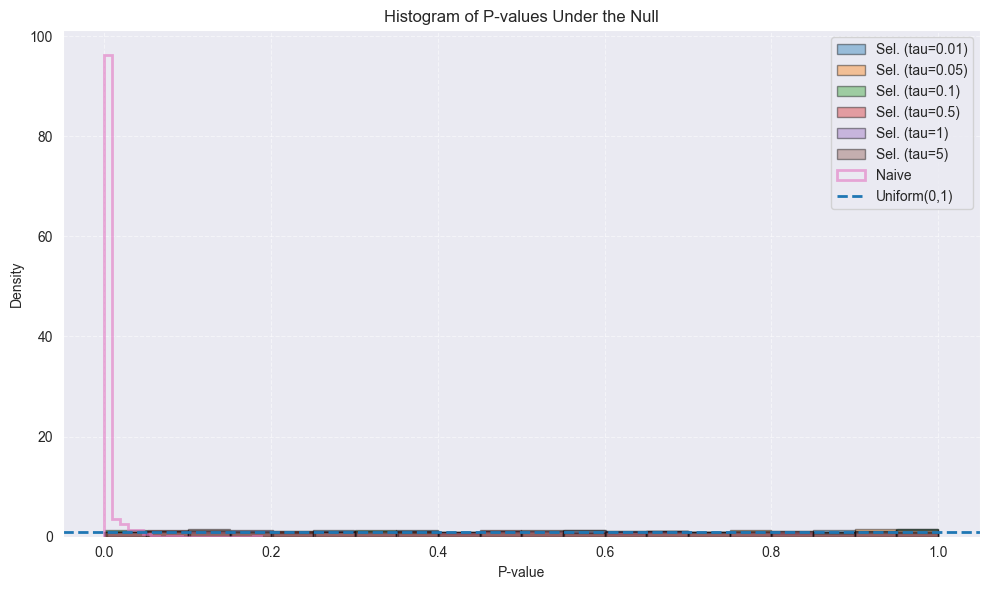

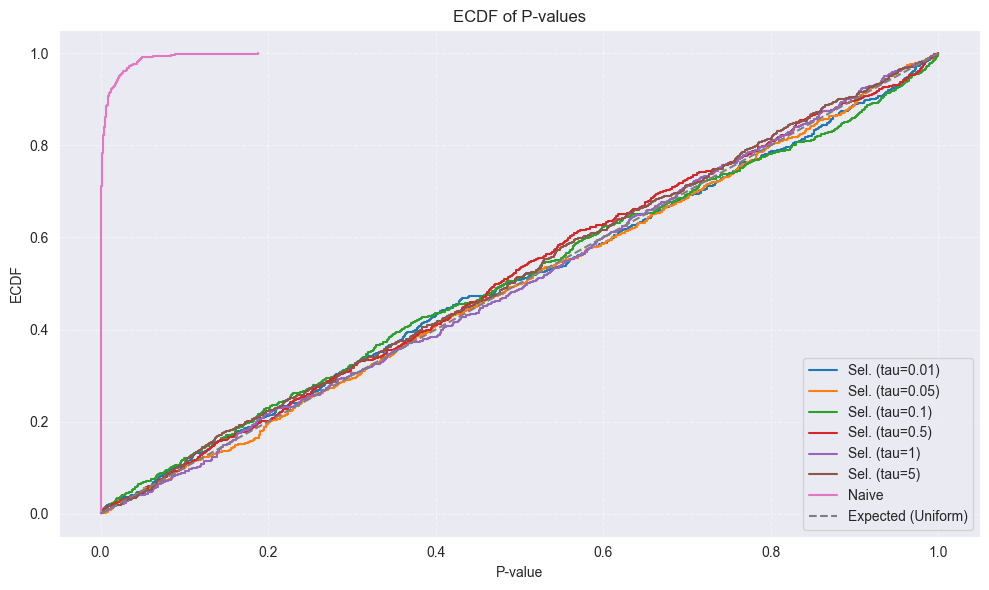

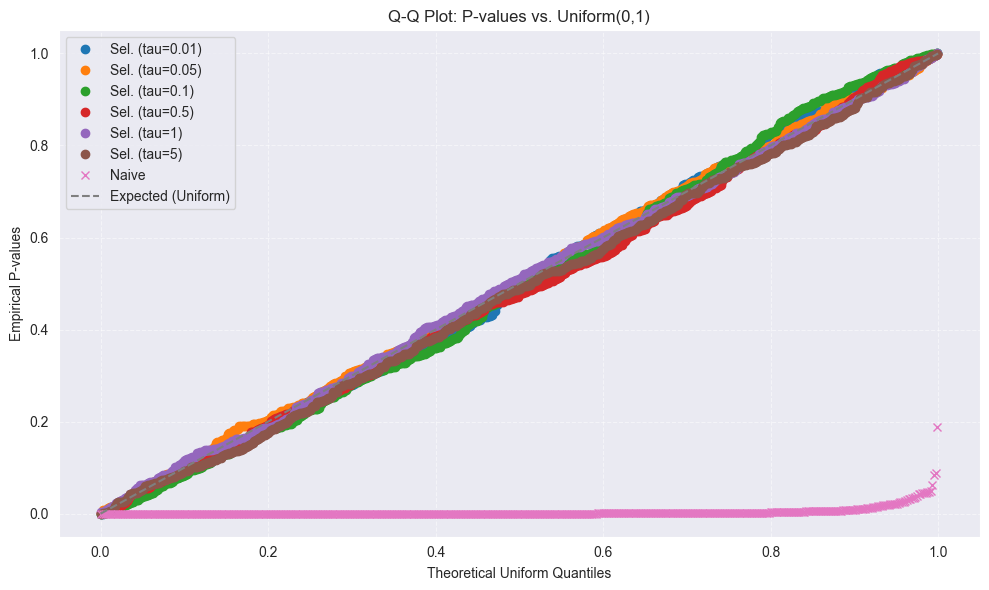

In [16]:
df = pd.read_csv("/Users/judydw/Downloads/pval_data_randomized.csv")
tau_cols = [c for c in df.columns if c.startswith('tau=')]
naive = df['naive'].dropna().to_numpy()
plt.figure(figsize=(10, 6))
for col in tau_cols:
    vals = df[col].dropna().to_numpy()
    plt.hist(vals, bins=20, density=True, alpha=0.4, edgecolor='black',
             label=f"Sel. ({col})")
plt.hist(naive, bins=20, density=True, alpha=0.6, histtype='step', linewidth=2,
         label="Naive")
plt.axhline(1, linestyle='--', linewidth=2, label="Uniform(0,1)")
plt.xlabel("P-value"); plt.ylabel("Density")
plt.title("Histogram of P-values Under the Null")
plt.legend(); plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout(); plt.show()

def plot_ecdf(values, label):
    x = np.sort(values)
    y = np.arange(1, len(x) + 1) / len(x)
    plt.step(x, y, where='post', label=label)

plt.figure(figsize=(10, 6))
for col in tau_cols:
    plot_ecdf(df[col].dropna().to_numpy(), f"Sel. ({col})")
plot_ecdf(naive, "Naive")
plt.plot([0, 1], [0, 1], linestyle="--", label="Expected (Uniform)")
plt.xlabel("P-value"); plt.ylabel("ECDF")
plt.title("ECDF of P-values")
plt.legend(); plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout(); plt.show()

plt.figure(figsize=(10, 6))
for col in tau_cols:
    vals = np.sort(df[col].dropna().to_numpy())
    n = len(vals)
    theo = (np.arange(1, n + 1) - 0.5) / n
    plt.plot(theo, vals, marker='o', linestyle='', label=f"Sel. ({col})")
vals_naive = np.sort(naive)
#vals_gao_c = np.sort(gao_c)
n0 = len(vals_naive)
theo0 = (np.arange(1, n0 + 1) - 0.5) / n0
plt.plot(theo0, vals_naive, marker='x', linestyle='', label="Naive")
#plt.plot(theo0, vals_gao_c, marker='x', linestyle='', label="Gao et al.(sigma_clustered)")
plt.plot([0, 1], [0, 1], linestyle="--", label="Expected (Uniform)")
plt.xlabel("Theoretical Uniform Quantiles")
plt.ylabel("Empirical P-values")
plt.title("Q-Q Plot: P-values vs. Uniform(0,1)")
plt.legend(); plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout(); plt.show()

In [11]:
random.seed(0)
p= 10
mu = np.zeros(p)
X = generate_null_data(30,p,mu,1)

grid_width = 20
model = AgglomerativeClustering(X, tau=0.01, n_clusters=3, linkage="complete")
model.fit()
c1 = model.K_clusters[0]
c2 = model.K_clusters[1]
m = len(c1.points) + len(c2.points)
dfn = p
dfd = p* (m-2)

p_val, obs, sel_prob,low,high = model.merge_inference_F_random_pair_grid(c1,c2,grid_width=grid_width, ncoarse = 20, ngrid=2000)
p_val1, obs1, sel_prob1 = model.merge_inference_F_random_pair(c1,c2,grid_width=grid_width, ncoarse = 20, ngrid=2000)
grid = np.linspace(0.00001, grid_width, num=2000)
grid_short = np.linspace(low, high, 2000)
uncorrected = f.pdf(grid,dfn, dfd)
sel_log = np.asarray(sel_prob).reshape(-1)
assert sel_log.shape[0] == grid.shape[0]

log_prior = f.logpdf(grid, dfn, dfd)           
log_post  = log_prior + sel_log              
dx      = np.gradient(grid)
unnorm  = np.exp(log_post - log_post.max())
Z       = (unnorm * dx).sum() + 1e-300
corr_pdf = unnorm / Z                       

sel_log1 = np.asarray(sel_prob1).reshape(-1)
assert sel_log1.shape[0] == grid.shape[0]
       
log_post1  = log_prior + sel_log1   
unnorm1  = np.exp(log_post1 - log_post1.max())
Z1       = (unnorm1 * dx).sum() + 1e-300
corr_pdf1 = unnorm1 / Z1

plt.figure(figsize=(8,5))
plt.plot(grid, f.pdf(grid, dfn, dfd), label='uncorrected F', alpha=0.8)
plt.plot(grid_short, corr_pdf, label='selection-corrected (normalized, short)', linewidth=2)

plt.plot(grid, corr_pdf1, label='selection-corrected (normalized)', linewidth=2)
plt.axvline(obs, ls='--', color='k', alpha=0.7, label=f'observed = {obs:.3g}')

mask = grid_short >= obs
plt.fill_between(grid_short[mask], 0, corr_pdf[mask], alpha=0.25, label=f'corrected tail ≈ {p_val:.3f}')

plt.xlabel('F-statistic (g)')
plt.ylabel('density')
plt.title('F vs. selection-corrected density')
plt.legend()
plt.tight_layout()
plt.show()

1e-05 7.012367998197821


ValueError: not enough values to unpack (expected 5, got 3)

In [3]:
p_val

np.float64(0.7140258687450719)

In [4]:
w  = corr_pdf * dx
cdf = np.cumsum(w)
cdf /= cdf[-1]
q_low, q_high = 0.005, 0.995
low  = np.interp(q_low,  cdf, grid)
high = np.interp(q_high, cdf, grid)
print(low, high)

7.550100805211367 11.012673516747547


In [4]:
def check_p_value_uniformity(n, p, sigma, K, tau, linkage="complete", num_trials=1000):
    p_values = []
    p_values_n = []
    mu = np.zeros(p)

    while len(p_values_n) < num_trials:
        X = generate_null_data(n, p, mu, sigma)
        model = AgglomerativeClustering(X, tau=tau, n_clusters=K, linkage=linkage)
        model.fit()

        c1 = model.K_clusters[0]
        c2 = model.K_clusters[1]
        p_value, obs,sel_prob = model.merge_inference_F_random_pair_grid(c1,c2, grid_width=70, ncoarse=20, ngrid=2000) 
        p_value_n = naive_p_value_random_pair(X, K, linkage)
        if not (np.isnan(p_value) and np.isnan(p_value_n)):
            p_values.append(p_value)
            p_values_n.append(p_value_n)
    p_values = np.array(p_values)
    p_values_n = np.array(p_values_n)

    # Histogram for both p-values
    plt.figure(figsize=(8, 5))
    plt.hist(p_values, bins=20, density=True, alpha=0.5, color="blue", edgecolor="black",
             label="Selection-based p-value")
    plt.hist(p_values_n, bins=20, density=True, alpha=0.5, color="orange", edgecolor="black", label="Naive p-value")
    plt.axhline(1, color='red', linestyle='dashed', linewidth=2, label="Uniform(0,1)")
    plt.xlabel("P-value")
    plt.ylabel("Density")
    plt.title("Histogram of P-values Under the Null Hypothesis")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

    plt.figure(figsize=(8, 5))
    sns.ecdfplot(p_values, color="blue", label="Selection-based p-values")
    sns.ecdfplot(p_values_n, color="orange", label="Naive p-values")
    plt.plot([0, 1], [0, 1], linestyle="--", color="red", label="Expected (Uniform)")
    plt.xlabel("P-value")
    plt.ylabel("ECDF")
    plt.title("Empirical CDF of P-values")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

    # Q-Q Plot for both p-values
    plt.figure(figsize=(8, 5))
    sorted_p_values = np.sort(p_values)
    sorted_p_values_n = np.sort(p_values_n)
    theoretical_quantiles = np.linspace(0, 1, num_trials)

    plt.plot(theoretical_quantiles, sorted_p_values, marker='o', linestyle='', color="blue",
             label="Selection-based p-values")
    plt.plot(theoretical_quantiles, sorted_p_values_n, marker='o', linestyle='', color="orange", label="Naive p-values")
    plt.plot([0, 1], [0, 1], linestyle="--", color="red", label="Expected (Uniform)")
    plt.xlabel("Theoretical Uniform Quantiles")
    plt.ylabel("Empirical P-values")
    plt.title("Q-Q Plot: P-values vs. Uniform(0,1)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

7.402748204828004 55.498715096954314
19.866093350650907 70.0
2.327471080349172 28.938865210329098
6.7736556160951 26.261827411098704
3.271961770802399 56.22854434930738
2.024396481003027 59.3335767362782
5.270282636867083 53.861145497658825
10.112650517726802 60.39431364475622
0.2659846492226876 43.1183526076086
2.2699467958371393 40.1029781901386
1e-05 29.114375932731516
5.151793143882102 50.937404962476236
0.03220334858179186 40.79713870033301
1e-05 46.06215627692743
4.313190037723826 24.919448188485802
1.2985504433540136 39.95099793757082
1.8937150319227989 8.833566633150292
1e-05 39.169468876772704
1e-05 26.167472059592512
1e-05 36.51818025709082
1.46647216504768 48.643558156247074
3.698214861328335 39.876624483180265
1.48045410612335 24.199146124833042
0.04115449616859035 19.400159897432086
1e-05 29.5529702300801
1e-05 34.29705097311712
1e-05 41.79453809221898
0.05943741874493824 41.0168644748761
2.186079881121234 39.30380649450615
1e-05 21.90363787935558
1e-05 47.71948578066722
2

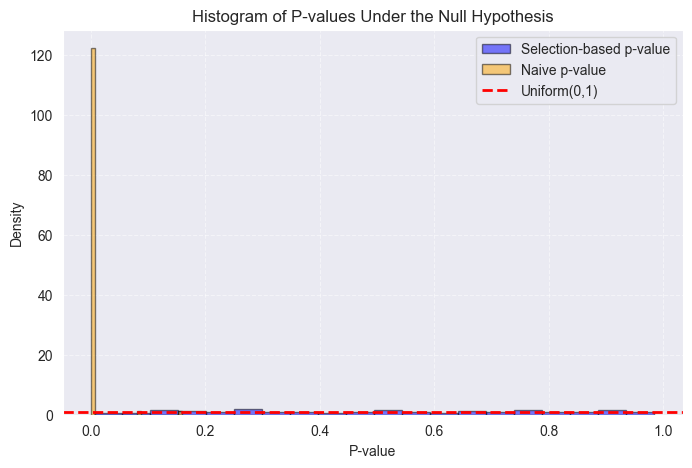

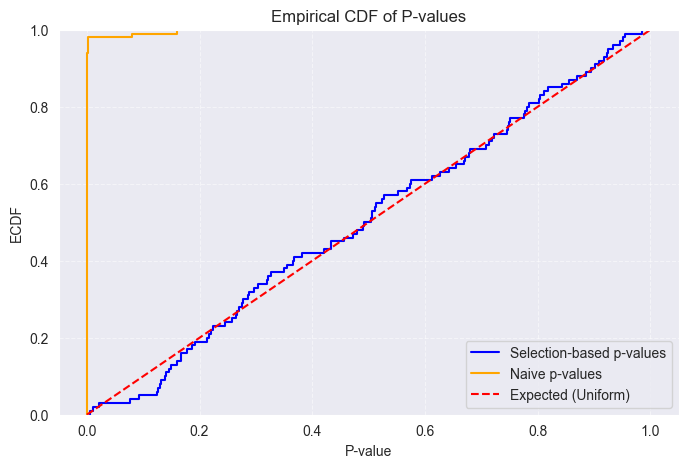

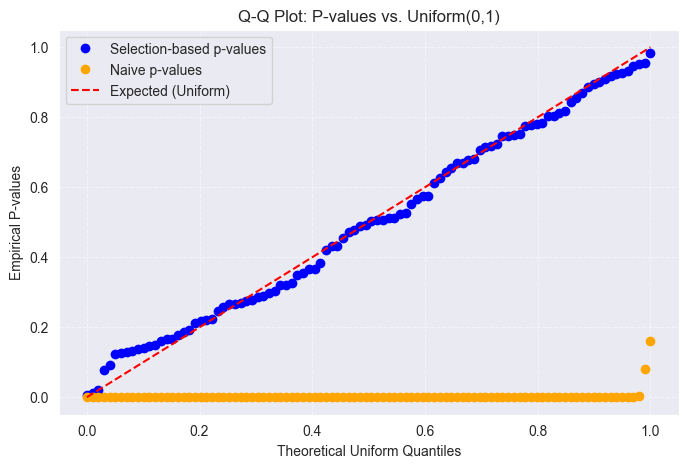

In [6]:
check_p_value_uniformity(30,2,1,3,0.01,"complete", 100)

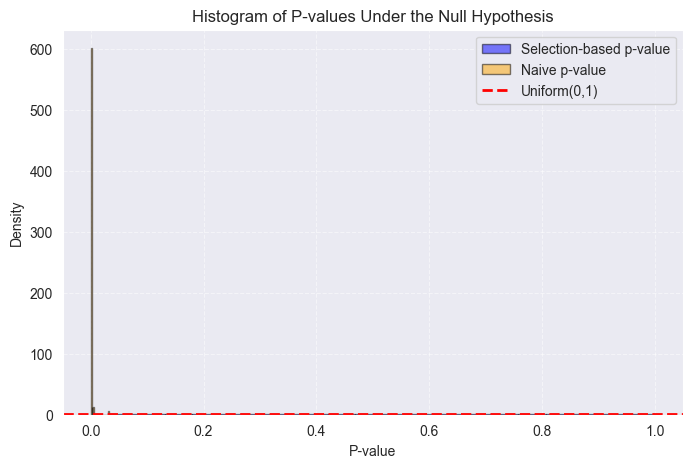

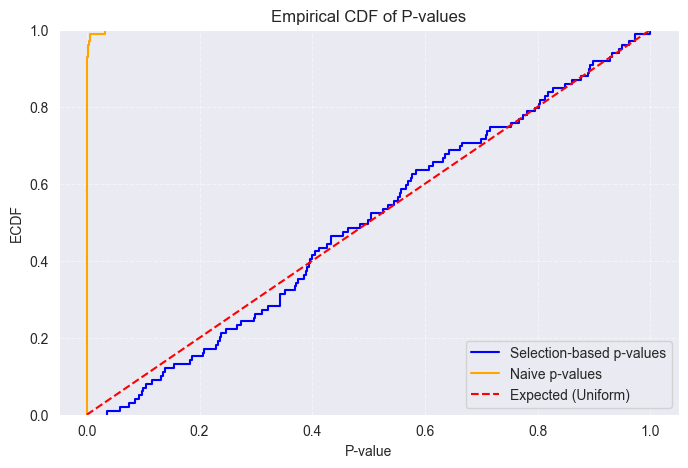

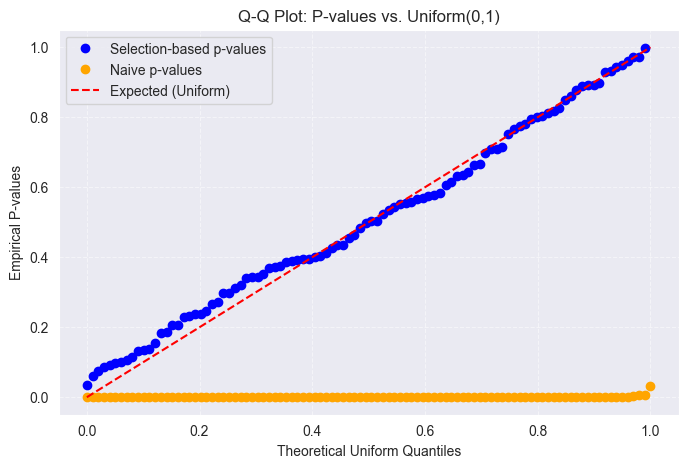

In [9]:
check_p_value_uniformity(30,2,1,3,0.01,"complete", 100)